# 07MIAR - Redes Neuronales y Deep Learning: Proyecto de programación "*Deep Vision in classification tasks*"


## Enunciado

En esta actividad, el alumno debe **evaluar y comparar dos estrategias** para la **clasificación de imágenes** empleando el **dataset asignado**. Los alumnos deberá resolver el reto proponiendo una solución válida **basada en aprendizaje profundo**, más concretamente en redes neuronales convolucionales (**CNNs**). Será indispensable que la solución propuesta siga el **pipeline visto en clase** para resolver este tipo de tareas de inteligencia artificial:

1.   **Carga** del conjunto de datos
2.   **Inspección** del conjunto de datos
3.   **Acondicionamiento** del conjunto de datos
4.   Desarrollo de la **arquitectura** de red neuronal y **entrenamiento** de la solución
5.   **Monitorización** del proceso de **entrenamiento** para la toma de decisiones
6.   **Evaluación** del modelo predictivo y planteamiento de la siguiente prueba experimental

### Estrategia 1: Entrenar desde cero o *from scratch*

La primera estrategia a comparar será una **red neuronal profunda** que el **alumno debe diseñar, entrenar y optimizar**. Se debe **justificar empíricamente** las decisiones que llevaron a la selección de la **arquitectura e hiperparámetros final**. Se espera que el alumno utilice todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

### Estrategia 2: Red pre-entrenada

La segunda estrategia a comparar debe incluir la utilización de una **red preentrenada** con el dataset ImageNet, llevando a cabo tareas de ***transfer learning*** y ***fine-tuning*** para resolver la tarea de clasificación asignada. Deben **compararse al menos dos tipos de arquitecturas** (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet) y se debe **seleccionar la que mayor precisión proporcione** (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera el uso de todas las **técnicas de regularización** mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (*weight regularization*, *dropout*, *batch normalization*, *data augmentation*, etc.).

## Normas a seguir

- Será **indispensable** realizar el **trabajo por parejas**. Dichas parejas de alumnxs se generarán **de manera automática** teniendo en cuenta el pais de residencia con el objetivo de facilitar el trabajo en equipo.  
- Se debe entregar un **ÚNICO FICHERO PDF POR ALUMNO** que incluya las instrucciones presentes en el Colab Noteboook y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso llevado a cabo en cada estrategia (i.e. carga de datos, inspección de datos, acondicionamiento, proceso de entrenamiento y proceso de validación del modelo).
- **La memoria del trabajo** (el fichero PDF mencionado en el punto anterior) deberá **subirla cada integrante del grupo** (aunque se trate de un documento idéntico) a la actividad que se habilitará **en CampusVIU**.
- Se recomienda trabajar respecto a un directorio base (**BASE_FOLDER**) para facilitar el trabajo en equipo. En este notebook se incluye un ejemplo de cómo almacenar/cargar datos utilizando un directorio base.
- Las **redes propuestas** deben estar **entrenadas** (y **EVIDENCIAR este proceso en el documento PDF**). La entrega de una **red sin entrenar** supondrá **perdida de puntos**.
- Si se desea **evidenciar alguna métrica** del proceso de entrenamiento (precisión, pérdida, etc.), estas deben ser generadas.
- Todos los **gráficos** que se deseen mostrar deberán **generarse en el Colab Notebook** para que tras la conversión aparezcan en el documento PDF.

## *Tips* para realizar la actividad con éxito
- Los **datos** se cargarán directamente **desde** la plataforma **Kaggle** mediante su API (https://github.com/Kaggle/kaggle-api). En este Notebook se incluye un ejemplo de como hacerlo. Se recomienda generar una función que aborde esta tarea.
- El **documento PDF a entregar** como solución de la actividad se debe **generar automáticamente desde el fichero ".ipynb"**. En este Notebook se incluye un ejemplo de como hacerlo.
- **Generar secciones y subsecciones en el Colab Notebook** supondrá que el documento **PDF generado** queda totalmente **ordenado** facilitando la evaluación al docente.
- Se recomienda encarecidamente **incluir comentarios concisos pero aclaratorios**.
- Es muy recomendable crear una **última sección** de texto en el Colab Notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterios de evaluación

- **Seguimiento** de las **normas establecidas** en la actividad (detalladas anteriormente).
- Creación de una **solución que resuelva la tarea de clasificación**, i.e. que las figuras de mérito empleadas para medir la bondad del modelo predictivo evidencien un *performance* superior al rendimiento estocástico.
- **Claridad** en la creación de la solución, en las justificaciones sobre la toma de decisiones llevada a cabo así como en las comparativas y conclusiones finales.
- **Efectividad** al presentar las comparaciones entre métricas de evaluación de ambas estrategias.
- **Demostración** de la utilización de **técnicas de regularización** para mejorar el rendimiento de los modelos.

## 1. Configuración del entorno y carga de librerías

In [1]:
# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import (
    MobileNetV2, ResNet50, VGG16, InceptionV3
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga de datos desde la plataforma Kaggle

In [2]:
# En primer lugar se debe generar un API de Kaggle personal, para ello:
#  1. Registrarse en  https://www.kaggle.com
#  2. Ir a 'Account tab' de tu perfil y seleccionar 'Create API Token'
#  3. Almacenar en tu ordenador local el fichero kaggle.json

In [3]:
# Nos aseguramos que tenemos instalada la última versión de la API de Kaggle en Colab
!pip uninstall -y kaggle kagglesdk
!pip install --no-cache-dir kaggle

Found existing installation: kaggle 2.0.2
Uninstalling kaggle-2.0.2:
  Successfully uninstalled kaggle-2.0.2
Found existing installation: kagglesdk 0.1.20
Uninstalling kagglesdk-0.1.20:
  Successfully uninstalled kagglesdk-0.1.20
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 67.9 MB/s eta 0:00:00


In [4]:
# Seleccionar el API Token personal previamente descargado (fichero kaggle.json)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jugauno","key":"KGAT_5db62b3ea3691e462572e64b96713c36"}'}

In [5]:
# Creamos un directorio en el que copiamos el fichero kaggle.json
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
# Ya podemos listar los datasets disponibles en kaggle para su descarga
!kaggle datasets list

ref                                                              title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                   Social Media Impact on Teen Mental Health               16190  2026-04-05 08:04:21.823000          26850        576                1  
sharmajicoder/gen-z-social-media-usage-dataset                   Gen-Z Social Media Usage Dataset                     44185801  2026-04-25 08:23:33.093000           3861         80                1  
payaldhokane/stress-analysis-in-social-media-dataset             Stress Analysis in Social Media Dataset               1373504  2026-05-08 12:42:27.390000            688         27                1  


In [7]:
# IMPORTANTE ANTES DE DESCARGAR UN DATASET !!!
# Antes de descargar el dataset debemos ir a https://www.kaggle.com/c/$nameCompetition/data y aceptar las "Competition Rules"
# En caso de no realizar el paso anterior al descargar el dataset obtenedremos el siguiente mensaje "403 - Forbidden"
# AHORA SI: Descarguemos un dataset de cierta competición
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri
#NOTA: El nombre del dataset de competición a descargar se informará en el documento en el que se presenten las parejas formadas

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
100% 86.8M/86.8M [00:01<00:00, 83.8MB/s]



In [8]:
# Creemos un directorio para descomprimir los datos
!mkdir my_dataset

In [9]:
# Descomprimimos los datos y los dejamos listos para trabajar
!unzip brain-tumor-classification-mri.zip -d my_dataset

Archive:  brain-tumor-classification-mri.zip
  inflating: my_dataset/Testing/glioma_tumor/image(1).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(10).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(100).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(11).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(12).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(13).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(14).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(15).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(16).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(17).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(18).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(19).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(2).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(20).jpg  
  inflating: my_dataset/Testing/glioma_tumor/image(21).jpg  
  inflating: my_dataset/Testing/glioma_tu

In [10]:
#%%capture
!cd testing/
!ls

/bin/bash: line 1: cd: testing/: No such file or directory
brain-tumor-classification-mri.zip  kaggle.json  my_dataset  sample_data


### Ejemplo de escritura de datos tomando como referencia un BASE_FOLDER

In [11]:
# Conectamos con nuestro Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# Establezco una ruta absoluta a un directorio existente de mi Google Drive
BASE_FOLDER = "/content/drive/MyDrive/07MIAR_Proyecto_Programacion/"

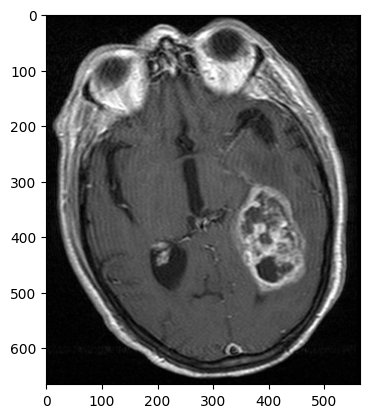

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Escogiendo y mostrando una imagen al azar del conjunto de test
idx = np.random.randint(1, 101)
img = cv2.imread('my_dataset/Testing/glioma_tumor/image(' + str(idx) + ').jpg', cv2.COLOR_BGR2RGB)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [14]:
# Almacenando una imagen aleatoria de test en mi BASE_FOLDER
cv2.imwrite(BASE_FOLDER + 'brain_tumor.jpg', img)

False

## 3. Revisión del dataset

In [15]:
#Definimos rutas de las carpetas del dataset
BASE_FOLDER   = '/content/my_dataset'
TRAIN_DIR     = os.path.join(BASE_FOLDER, 'Training')
TEST_DIR      = os.path.join(BASE_FOLDER, 'Testing')

CLASSES       = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES   = len(CLASSES)
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32

print('Clases detectadas:', CLASSES)
print('Número de clases:', NUM_CLASSES)

Clases detectadas: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Número de clases: 4


In [16]:
# Funcion que cuenta el número de imágenes por clase en un directorio.
def contar_imagenes(directorio):
    conteo = {}
    for clase in sorted(os.listdir(directorio)):
        ruta_clase = os.path.join(directorio, clase)
        if os.path.isdir(ruta_clase):
            conteo[clase] = len([
                f for f in os.listdir(ruta_clase)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
    return conteo

conteo_train = contar_imagenes(TRAIN_DIR)
conteo_test  = contar_imagenes(TEST_DIR)

print('Conjunto de Entrenamiento')
for clase, n in conteo_train.items():
    print(f'  {clase}: {n} imágenes')
print(f'  TOTAL: {sum(conteo_train.values())}')

print('Conjunto de Test')
for clase, n in conteo_test.items():
    print(f'  {clase}: {n} imágenes')
print(f'  TOTAL: {sum(conteo_test.values())}')

Conjunto de Entrenamiento
  glioma_tumor: 826 imágenes
  meningioma_tumor: 822 imágenes
  no_tumor: 395 imágenes
  pituitary_tumor: 827 imágenes
  TOTAL: 2870
Conjunto de Test
  glioma_tumor: 100 imágenes
  meningioma_tumor: 115 imágenes
  no_tumor: 105 imágenes
  pituitary_tumor: 74 imágenes
  TOTAL: 394


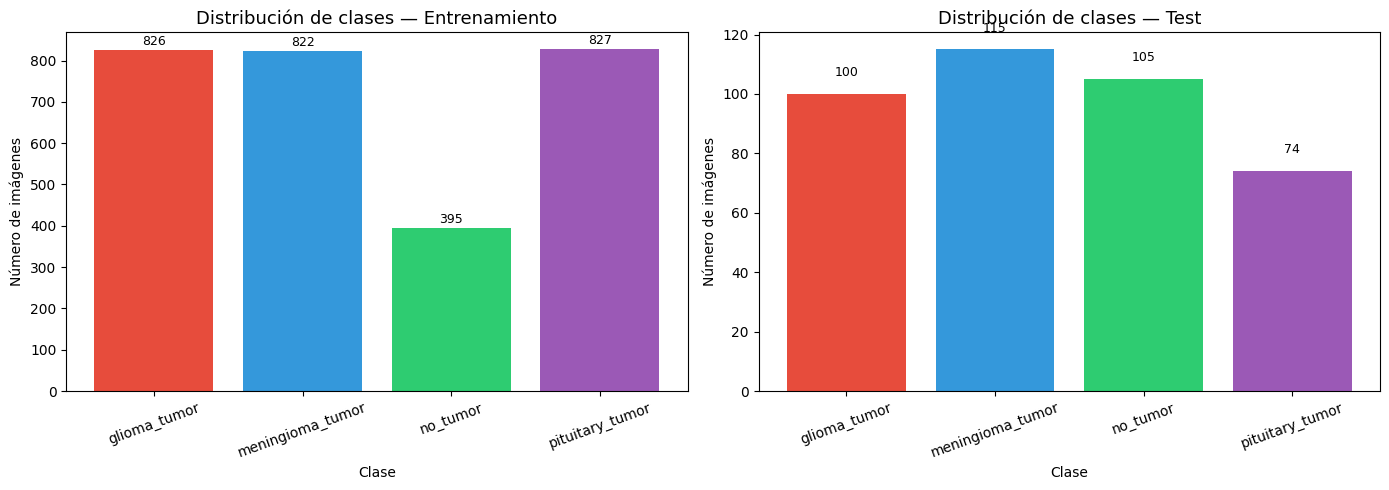

In [17]:
# Visualización de la distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (conteo, titulo) in zip(axes, [
    (conteo_train, 'Entrenamiento'),
    (conteo_test,  'Test')
]):
    bars = ax.bar(conteo.keys(), conteo.values(),
                  color=['#e74c3c','#3498db','#2ecc71','#9b59b6'])
    ax.set_title(f'Distribución de clases — {titulo}', fontsize=13)
    ax.set_xlabel('Clase')
    ax.set_ylabel('Número de imágenes')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(int(bar.get_height())),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BASE_FOLDER, 'distribucion_clases.png'), dpi=150)
plt.show()

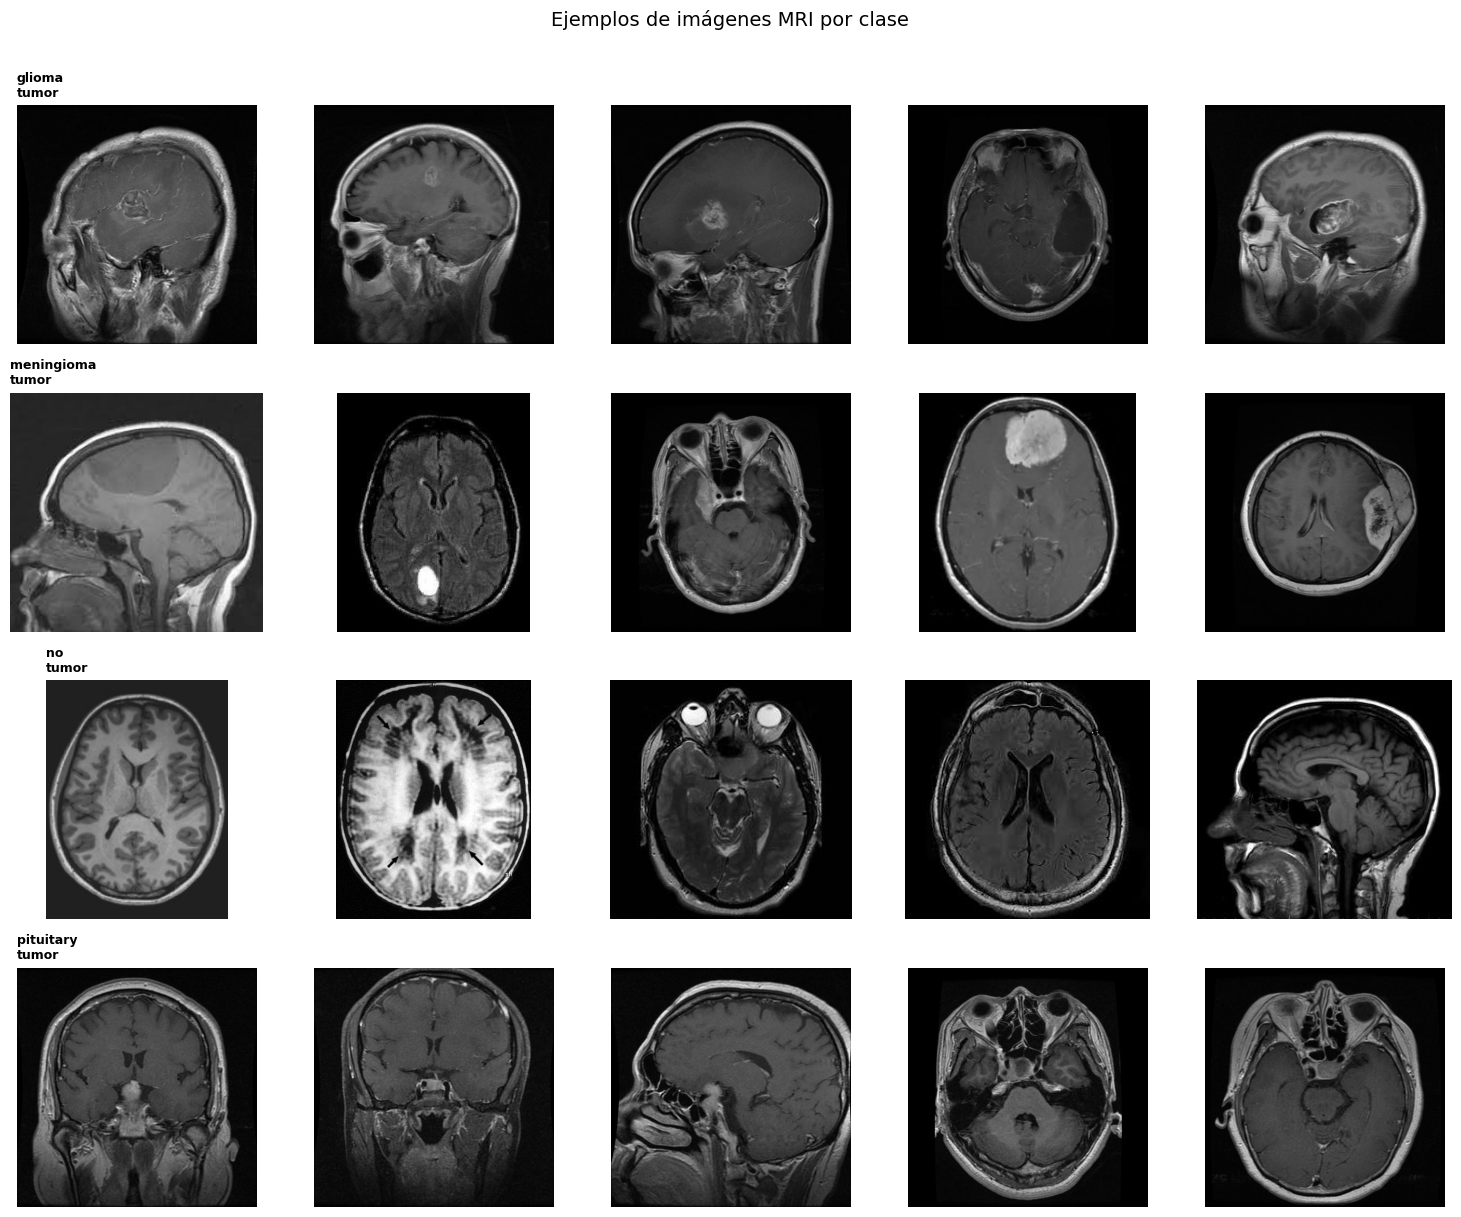

In [18]:
# Mostrar ejemplos de cada clase
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 12))

for i, clase in enumerate(CLASSES):
    ruta_clase = os.path.join(TRAIN_DIR, clase)
    imagenes   = random.sample(os.listdir(ruta_clase), 5)
    for j, nombre in enumerate(imagenes):
        img = mpimg.imread(os.path.join(ruta_clase, nombre))
        axes[i, j].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(clase.replace('_', '\n'), fontsize=9,
                                  fontweight='bold', loc='left')

plt.suptitle('Ejemplos de imágenes MRI por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_FOLDER, 'muestras_por_clase.png'), dpi=150)
plt.show()

In [19]:
# Inspección de dimensiones de las imágenes
dimensiones = []
for clase in CLASSES:
    ruta_clase = os.path.join(TRAIN_DIR, clase)
    for fname in os.listdir(ruta_clase)[:30]:  # muestreo de 30 por clase
        img = cv2.imread(os.path.join(ruta_clase, fname))
        if img is not None:
            dimensiones.append(img.shape[:2])

alturas  = [d[0] for d in dimensiones]
anchuras = [d[1] for d in dimensiones]

print(f'Altura  — min: {min(alturas)}, max: {max(alturas)}, media: {np.mean(alturas):.1f}')
print(f'Anchura — min: {min(anchuras)}, max: {max(anchuras)}, media: {np.mean(anchuras):.1f}')
print(f'\nSe redimensionarán todas las imágenes a {IMG_SIZE} para homogeneizar el dataset.')

Altura  — min: 198, max: 680, media: 453.1
Anchura — min: 201, max: 1000, media: 452.8

Se redimensionarán todas las imágenes a (224, 224) para homogeneizar el dataset.


## 4. Acondicionamiento del dataset

Se aplica:
- **Redimensionado** a 224×224 píxeles
- **Normalización** de los valores de píxel al rango [0, 1]
- **Data Augmentation** solo sobre el conjunto de entrenamiento para incrementar la diversidad de ejemplos y reducir el sobreajuste

In [20]:
# Data augmentation y normalización para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Solo normalización para test
test_datagen = ImageDataGenerator(rescale=1./255)

# Generadores
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Mapeo de clases:', train_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
Mapeo de clases: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


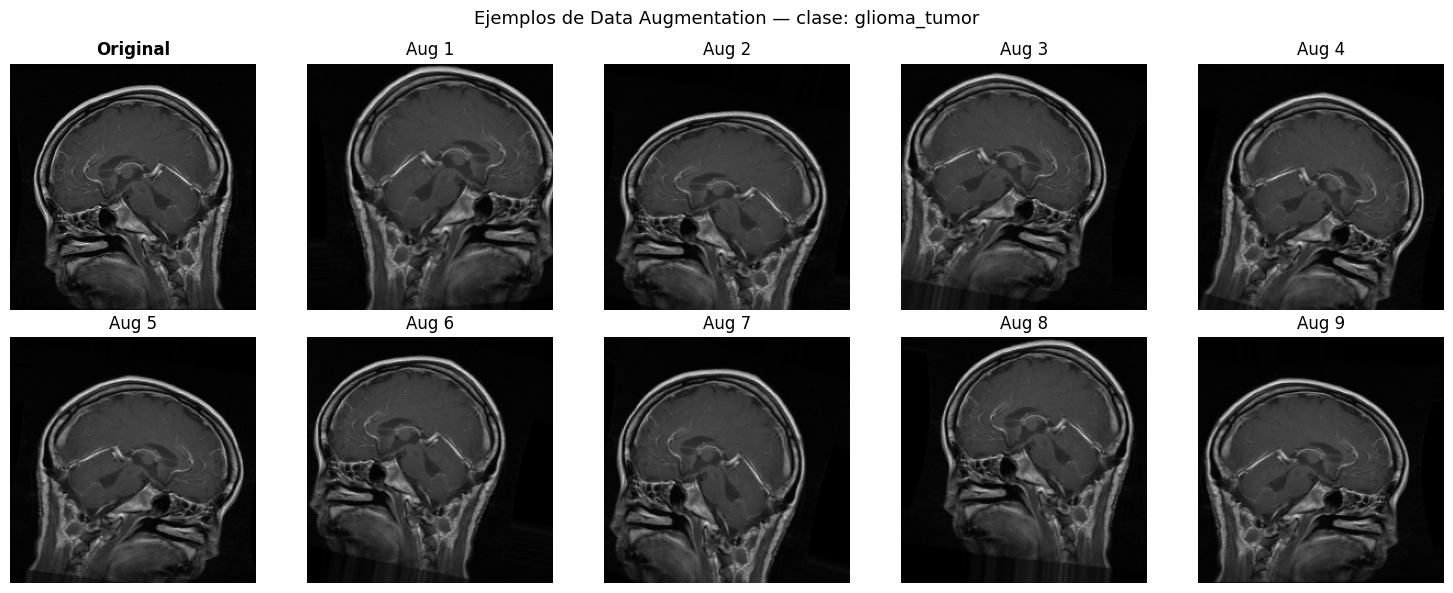

In [21]:
# Visualización del efecto del Data Augmentation
clase_ejemplo = CLASSES[0]
ruta_img      = os.path.join(TRAIN_DIR, clase_ejemplo,
                              os.listdir(os.path.join(TRAIN_DIR, clase_ejemplo))[0])
img_orig      = cv2.cvtColor(cv2.imread(ruta_img), cv2.COLOR_BGR2RGB)
img_orig      = cv2.resize(img_orig, IMG_SIZE)
img_array     = img_orig.reshape((1,) + img_orig.shape).astype('float32') / 255.

aug_gen = ImageDataGenerator(
    rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.1,
    zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(img_orig)
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for idx, img_aug in enumerate(aug_gen.flow(img_array, batch_size=1, seed=SEED)):
    row, col = divmod(idx + 1, 5)
    if row > 1: break
    axes[row, col].imshow(img_aug[0])
    axes[row, col].set_title(f'Aug {idx+1}')
    axes[row, col].axis('off')

for ax in axes.flat:
    if not ax.has_data(): ax.axis('off')

#Mostrar imagenes luego de aplicar Data Argumentation
plt.suptitle(f'Ejemplos de Data Augmentation — clase: {clase_ejemplo}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE_FOLDER, 'data_augmentation.png'), dpi=150)
plt.show()

## 5. Estrategia 1: CNN entrenada desde cero From Scratch

Se diseña una CNN propia con las siguientes técnicas de regularización:
- **Batch Normalization**: estabiliza y acelera el entrenamiento
- **Dropout**: reduce el sobreajuste al apagar neuronas aleatoriamente
- **L2 Regularization**: penaliza pesos grandes para generalización
- **Data Augmentation**: ya aplicada en el generador

In [22]:
# CNN personalizada y Regularización.
def build_cnn_scratch(input_shape=(224, 224, 3), num_classes=4):

    l2 = regularizers.l2(1e-4)

    model = models.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2, input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloque 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloque 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Bloque 4
        layers.Conv2D(256, (3, 3), padding='same', activation='relu',
                      kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Clasificador
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu', kernel_regularizer=l2),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_FromScratch')

    return model

model_scratch = build_cnn_scratch(input_shape=IMG_SIZE + (3,),
                                   num_classes=NUM_CLASSES)
model_scratch.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_FromScratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 652,836 (2.49 MB)

 Trainable params: 650,916 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [23]:
# Compilación
model_scratch.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_scratch = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(BASE_FOLDER, 'best_scratch.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

In [24]:
# Entrenamiento de la CNN desde cero
EPOCHS = 100

history_scratch = model_scratch.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_scratch,
    verbose=1
)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.5540 - loss: 1.2866
Epoch 1: val_accuracy improved from None to 0.29494, saving model to /content/my_dataset/best_scratch.keras

Epoch 1: finished saving model to /content/my_dataset/best_scratch.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 98s 964ms/step - accuracy: 0.6012 - loss: 1.1696 - val_accuracy: 0.2949 - val_loss: 1.7282 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6482 - loss: 1.0006
Epoch 2: val_accuracy improved from 0.29494 to 0.30541, saving model to /content/my_dataset/best_scratch.keras

Epoch 2: finished saving model to /content/my_dataset/best_scratch.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 566ms/step - accuracy: 0.6726 - loss: 0.9537 - val_accuracy: 0.3054 - val_loss: 3.0437 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.6849 - loss: 0.9296
Epoch 3: val_accuracy did not improve from 0.30541
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 548ms/

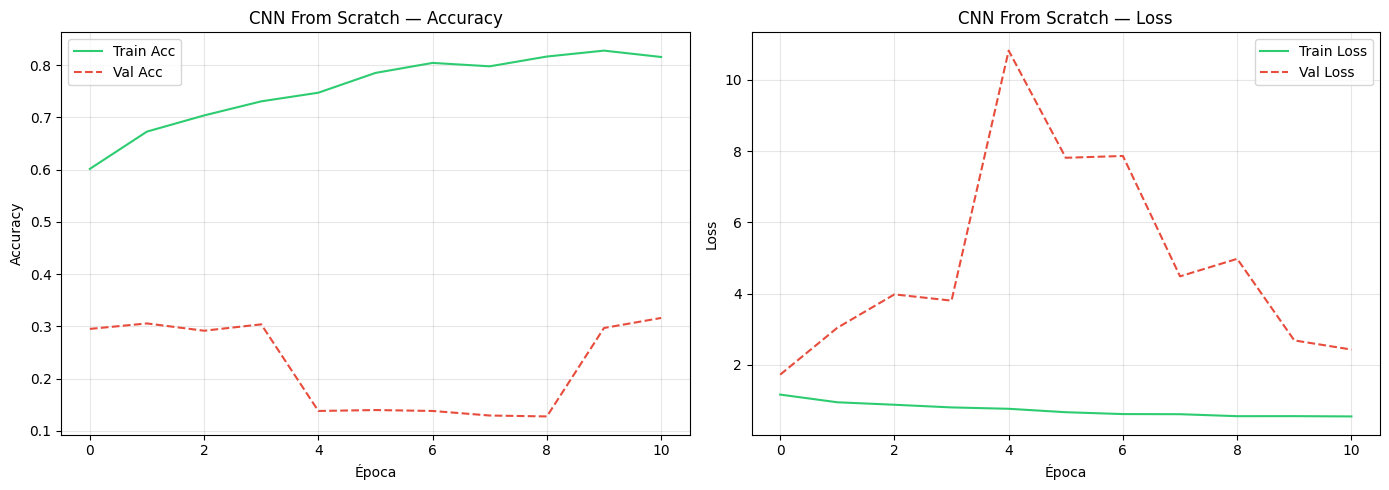

In [25]:
# Grafica las curvas de accuracy y loss de entrenamiento/validación
def plot_history(history, title='', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='#2ecc71')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='#e74c3c', linestyle='--')
    axes[0].set_title(f'{title} — Accuracy', fontsize=12)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='#2ecc71')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linestyle='--')
    axes[1].set_title(f'{title} — Loss', fontsize=12)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_history(
    history_scratch,
    title='CNN From Scratch',
    save_path=os.path.join(BASE_FOLDER, 'history_scratch.png')
)

  CNN From Scratch
  Loss en Test:     1.8710
  Accuracy en Test: 0.2259 (22.59%)

                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       100
meningioma_tumor       0.00      0.00      0.00       115
        no_tumor       0.56      0.14      0.23       105
 pituitary_tumor       0.20      1.00      0.34        74

        accuracy                           0.23       394
       macro avg       0.19      0.29      0.14       394
    weighted avg       0.19      0.23      0.12       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


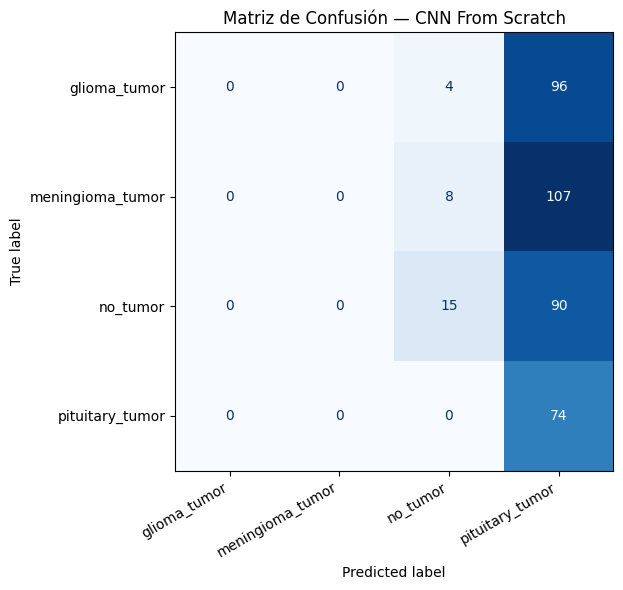

In [26]:
# Evalúa el modelo: loss, accuracy, classification report y matriz de confusión
def evaluar_modelo(model, generator, nombre_modelo='Modelo'):
    # Predicciones
    generator.reset()
    y_pred_proba = model.predict(generator, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = generator.classes
    clases       = list(generator.class_indices.keys())

    loss, acc = model.evaluate(generator, verbose=0)

    print(f'  {nombre_modelo}')
    print(f'  Loss en Test:     {loss:.4f}')
    print(f'  Accuracy en Test: {acc:.4f} ({acc*100:.2f}%)')
    print(f'\n{classification_report(y_true, y_pred, target_names=clases)}')

    # Matriz de confusión
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusión — {nombre_modelo}', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_FOLDER, f'cm_{nombre_modelo.replace(" ","_")}.png'), dpi=150)
    plt.show()

    return loss, acc

loss_scratch, acc_scratch = evaluar_modelo(
    model_scratch, test_generator, 'CNN From Scratch'
)

## 6. Estrategia 2: Transfer Learning y Fine-Tuning

Se comparan dos arquitecturas preentrenadas en ImageNet:
1. MobileNetV2 — ligera, eficiente
2. ResNet50 — residual connections, alta precisión

El proceso sigue dos fases:
- **Fase 1 (Feature Extraction):** se congelan las capas base y se entrena solo el clasificador
- **Fase 2 (Fine-Tuning):** se descongelan las últimas capas de la base para afinar los pesos

In [27]:
# Construye un modelo de Transfer Learning sobre una base preentrenada
def build_transfer_model(base_model_fn, input_shape=(224, 224, 3),
                          num_classes=4, nombre='TransferModel'):
    base = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base.trainable = False

    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=nombre)
    return model, base

In [28]:
# MobileNetV2 Construcción
model_mobilenet, base_mobilenet = build_transfer_model(
    MobileNetV2, input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES, nombre='MobileNetV2_BrainTumor'
)
model_mobilenet.summary()

# Fase 1: Feature Extraction
model_mobilenet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_mobilenet = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(BASE_FOLDER, 'best_mobilenet.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('\n[MobileNetV2] Fase 1: Feature Extraction')
history_mobilenet_fe = model_mobilenet.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=cb_mobilenet,
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,972 (9.87 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


[MobileNetV2] Fase 1: Feature Extraction
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.6508 - loss: 1.0649
Epoch 1: val_accuracy improved from None to 0.72077, saving model to /content/my_dataset/best_mobilenet.keras

Epoch 1: finished saving model to /content/my_dataset/best_mobilenet.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 88s 939ms/step - accuracy: 0.7283 - loss: 0.8473 - val_accuracy: 0.7208 - val_loss: 0.7374 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8328 - loss: 0.5189
Epoch 2: val_accuracy improved from 0.72077 to 0.80628, saving model to /content/my_dataset/best_mobilenet.keras

Epoch 2: finished saving model to /content/my_dataset/best_mobilenet.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 523ms/step - accuracy: 0.8306 - loss: 0.5202 - val_accuracy: 0.8063 - val_loss: 0.5906 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.8455 - loss: 0.4591
Epoch 3: val_accuracy did not improve 

In [29]:
# Fase 2: Fine-Tuning
base_mobilenet.trainable = True
for layer in base_mobilenet.layers[:-30]:
    layer.trainable = False

model_mobilenet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'[MobileNetV2] Capas entrenables: {sum(1 for l in model_mobilenet.layers if l.trainable)}')
print('\n[MobileNetV2] Fase 2: Fine-Tuning')

history_mobilenet_ft = model_mobilenet.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=cb_mobilenet,
    verbose=1
)

[MobileNetV2] Capas entrenables: 7

[MobileNetV2] Fase 2: Fine-Tuning
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.7507 - loss: 0.7055
Epoch 1: val_accuracy did not improve from 0.83421
72/72 ━━━━━━━━━━━━━━━━━━━━ 72s 738ms/step - accuracy: 0.7762 - loss: 0.6342 - val_accuracy: 0.7435 - val_loss: 0.8468 - learning_rate: 1.0000e-05
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8369 - loss: 0.5069
Epoch 2: val_accuracy did not improve from 0.83421
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 525ms/step - accuracy: 0.8276 - loss: 0.5118 - val_accuracy: 0.6963 - val_loss: 1.1308 - learning_rate: 1.0000e-05
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8536 - loss: 0.4531
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.83421
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 520ms/step - accuracy: 0.8489 - loss: 0.4517 - val_accuracy: 0.6632 - val_loss: 1.3165 - learning_rate: 1.0000e-05


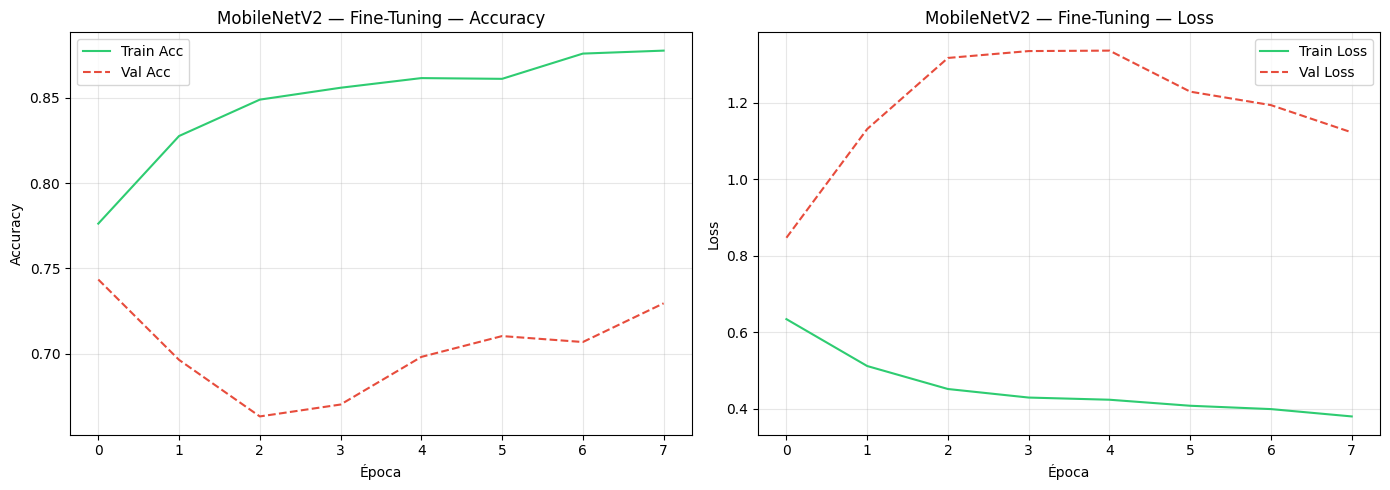

In [30]:
# Guarda las métricas de entrenamiento de un modelo.
plot_history(
    history_mobilenet_ft,
    title='MobileNetV2 — Fine-Tuning',
    save_path=os.path.join(BASE_FOLDER, 'history_mobilenet.png')
)

In [31]:
# ResNet50 - Construcción
model_resnet, base_resnet = build_transfer_model(
    ResNet50, input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES, nombre='ResNet50_BrainTumor'
)

# Fase 1: Feature Extraction
model_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_resnet = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(BASE_FOLDER, 'best_resnet.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('\n[ResNet50] Fase 1: Feature Extraction')
history_resnet_fe = model_resnet.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=cb_resnet,
    verbose=1
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

[ResNet50] Fase 1: Feature Extraction
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.5033 - loss: 1.2768
Epoch 1: val_accuracy improved from None to 0.29145, saving model to /content/my_dataset/best_resnet.keras

Epoch 1: finished saving model to /content/my_dataset/best_resnet.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 71s 773ms/step - accuracy: 0.5429 - loss: 1.1799 - val_accuracy: 0.2914 - val_loss: 1.4760 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.6142 - loss: 1.0091
Epoch 2: val_accuracy improved from 0.29145 to 0.35951, saving model to /content/my_dataset/best_resnet.keras

Epoch 2: finished saving model to /content/my_dataset/best_resnet.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 564ms/step - accuracy: 0.5951 - loss: 1.0428 - val_accuracy: 0.3595 - val_loss: 1.6160 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6041 - loss: 1.0035
Ep

In [32]:
# Fase 2: Fine-Tuning
base_resnet.trainable = True
for layer in base_resnet.layers[:-20]:
    layer.trainable = False

model_resnet.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('\n[ResNet50] Fase 2: Fine-Tuning')

history_resnet_ft = model_resnet.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=cb_resnet,
    verbose=1
)


[ResNet50] Fase 2: Fine-Tuning
Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.5279 - loss: 1.3917
Epoch 1: val_accuracy did not improve from 0.56719
72/72 ━━━━━━━━━━━━━━━━━━━━ 73s 758ms/step - accuracy: 0.5986 - loss: 1.1225 - val_accuracy: 0.2897 - val_loss: 7.9055 - learning_rate: 1.0000e-05
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.6454 - loss: 0.9646
Epoch 2: val_accuracy did not improve from 0.56719
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 550ms/step - accuracy: 0.6604 - loss: 0.8993 - val_accuracy: 0.2949 - val_loss: 4.2512 - learning_rate: 1.0000e-05
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6787 - loss: 0.8307
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.56719
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 558ms/step - accuracy: 0.6900 - loss: 0.8071 - val_accuracy: 0.2496 - val_loss: 3.0111 - learning_rate: 1.0000e-05
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━

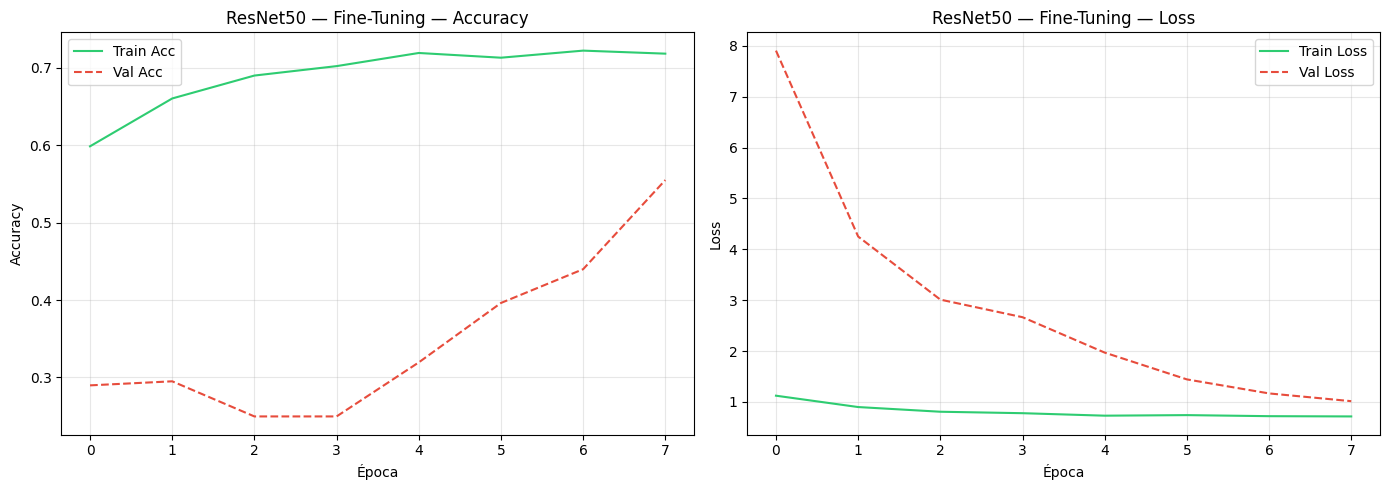

In [33]:
# Guarda y muestra las métricas de entrenamiento de un modelo.
plot_history(
    history_resnet_ft,
    title='ResNet50 — Fine-Tuning',
    save_path=os.path.join(BASE_FOLDER, 'history_resnet.png')
)

  MobileNetV2
  Loss en Test:     1.4728
  Accuracy en Test: 0.6015 (60.15%)

                  precision    recall  f1-score   support

    glioma_tumor       0.47      0.38      0.42       100
meningioma_tumor       0.56      0.63      0.59       115
        no_tumor       0.78      0.62      0.69       105
 pituitary_tumor       0.61      0.82      0.70        74

        accuracy                           0.60       394
       macro avg       0.61      0.61      0.60       394
    weighted avg       0.61      0.60      0.60       394



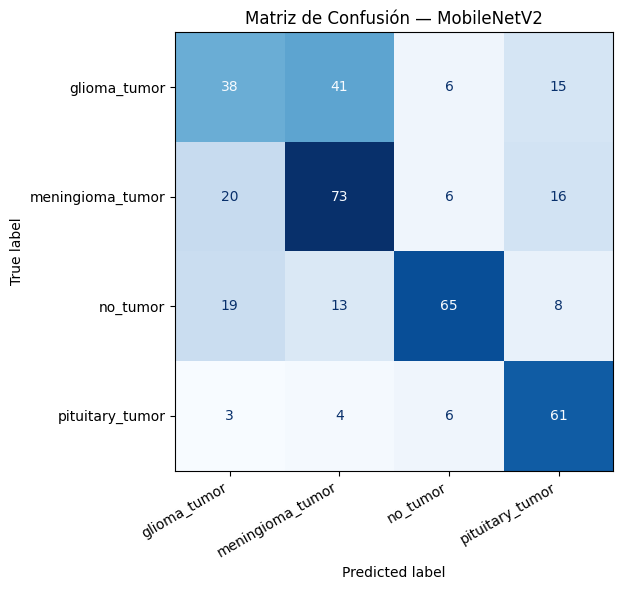

In [34]:
# Evaluación de los modelos de Transfer Learning - MobileNetV2
loss_mobilenet, acc_mobilenet = evaluar_modelo(
    model_mobilenet, test_generator, 'MobileNetV2'
)

  ResNet50
  Loss en Test:     6.5158
  Accuracy en Test: 0.3046 (30.46%)

                  precision    recall  f1-score   support

    glioma_tumor       0.26      0.81      0.40       100
meningioma_tumor       0.44      0.32      0.37       115
        no_tumor       1.00      0.02      0.04       105
 pituitary_tumor       0.00      0.00      0.00        74

        accuracy                           0.30       394
       macro avg       0.43      0.29      0.20       394
    weighted avg       0.46      0.30      0.22       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


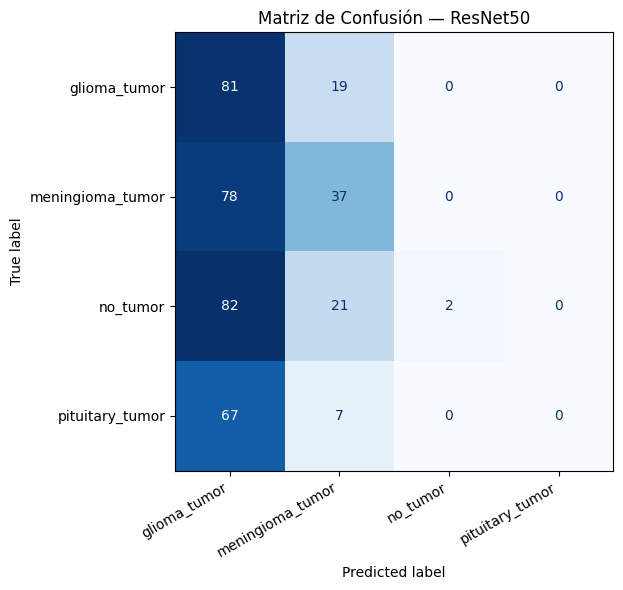

In [35]:
# Evaluación de los modelos de Transfer Learning - ResNet50
loss_resnet, acc_resnet = evaluar_modelo(
    model_resnet, test_generator, 'ResNet50'
)

## 7. Comparativa de todos los modelos

In [36]:
# Crear DataFrame
resultados = pd.DataFrame({
    'Modelo': ['CNN From Scratch', 'MobileNetV2', 'ResNet50'],
    'Accuracy (%)': [
        acc_scratch * 100,
        acc_mobilenet * 100,
        acc_resnet * 100
    ],
    'Loss': [
        loss_scratch,
        loss_mobilenet,
        loss_resnet
    ]
})

# Ordenar por accuracy
resultados = resultados.sort_values(
    by='Accuracy (%)',
    ascending=False
)

# Mostrar tabla bonita
display(
    resultados.style
    .format({
        'Accuracy (%)': '{:.2f}%',
        'Loss': '{:.4f}'
    })
    .highlight_max(subset=['Accuracy (%)'], color='green')
)

,Modelo,Accuracy (%),Loss
1,MobileNetV2,60.15%,1.4728
2,ResNet50,30.46%,6.5158
0,CNN From Scratch,22.59%,1.8710


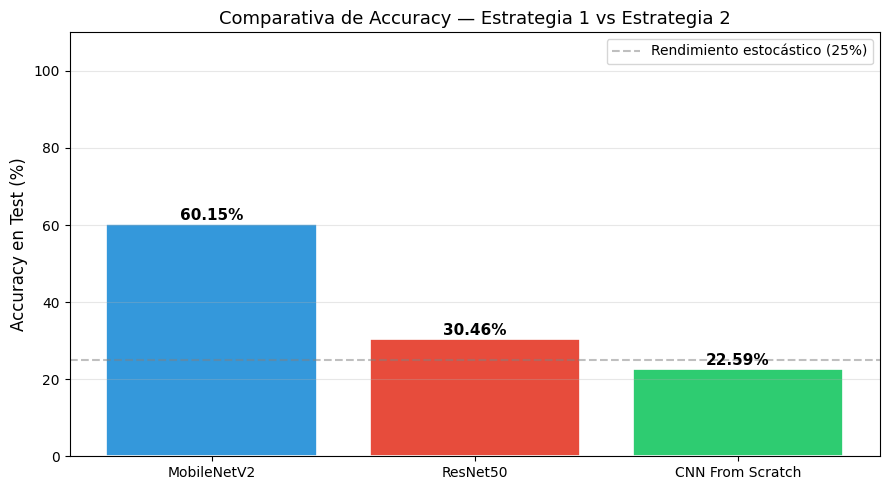

In [37]:
# Gráfico comparativo de accuracy
nombres    = resultados['Modelo'].tolist()
accuracies = resultados['Accuracy (%)'].tolist()
colores    = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(nombres, accuracies, color=colores, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy en Test (%)', fontsize=12)
ax.set_title('Comparativa de Accuracy — Estrategia 1 vs Estrategia 2', fontsize=13)
ax.axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Rendimiento estocástico (25%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_FOLDER, 'comparativa_modelos.png'), dpi=150)
plt.show()

## 8. Prueba de modelos detectando images

Sube una imagen MRI (JPG/PNG):


Saving image(1).jpg to image(1).jpg

Analizando: image(1).jpg


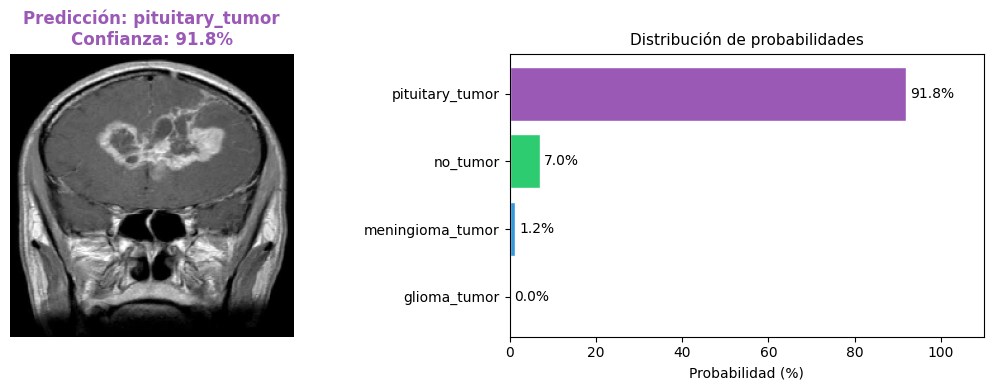

In [38]:
CLASSES   = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
COLORES   = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
IMG_SIZE  = (224, 224)

# Cargar el mejor modelo guardado
#modelo = tf.keras.models.load_model(os.path.join(BASE_FOLDER, 'best_resnet.keras'))
modelo = tf.keras.models.load_model(os.path.join(BASE_FOLDER, 'best_mobilenet.keras'))
#modelo = tf.keras.models.load_model(os.path.join(BASE_FOLDER, 'best_scratch.keras'))

def predecir_imagen(ruta, modelo, mostrar=True):
    img       = tf.keras.utils.load_img(ruta, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.
    img_batch = np.expand_dims(img_array, axis=0)

    probs     = modelo.predict(img_batch, verbose=0)[0]
    idx_pred  = np.argmax(probs)
    clase_pred = CLASSES[idx_pred]
    confianza  = probs[idx_pred]

    if mostrar:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        # Imagen original
        axes[0].imshow(img)
        color_titulo = COLORES[idx_pred]
        axes[0].set_title(f'Predicción: {clase_pred}\nConfianza: {confianza*100:.1f}%',
                          fontsize=12, color=color_titulo, fontweight='bold')
        axes[0].axis('off')

        # Barras de probabilidad
        barras = axes[1].barh(CLASSES, probs * 100, color=COLORES, edgecolor='white')
        axes[1].set_xlabel('Probabilidad (%)')
        axes[1].set_title('Distribución de probabilidades', fontsize=11)
        axes[1].set_xlim(0, 110)
        for bar, prob in zip(barras, probs):
            axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                         f'{prob*100:.1f}%', va='center', fontsize=10)

        plt.tight_layout()
        plt.show()

    return clase_pred, confianza, probs

# Subir imagen y predecir
print('Sube una imagen MRI (JPG/PNG):')
archivos = files.upload()

for nombre_archivo in archivos.keys():
    print(f'\nAnalizando: {nombre_archivo}')
    clase, conf, probs = predecir_imagen(nombre_archivo, modelo)

## 9. Conclusiones

### Estrategia 1 — CNN diseñada desde cero

La arquitectura CNN implementada manualmente incorporó cuatro bloques convolucionales junto con técnicas de regularización como Batch Normalization, Dropout y penalización L2. Además, se aplicó Data Augmentation para incrementar la variabilidad efectiva del conjunto de entrenamiento y reducir el sobreajuste.

### Estrategia 2 — Transfer Learning y Fine-Tuning

Los modelos basados en Transfer Learning mostraron un mejor desempeño respecto a la CNN entrenada desde cero. Esto confirma la efectividad de reutilizar características previamente aprendidas sobre grandes datasets como ImageNet, especialmente en escenarios médicos donde la disponibilidad de datos suele ser limitada.

Entre las arquitecturas evaluadas:

| Modelo | Accuracy | Loss |
|---|---:|---:|
| MobileNetV2 | 62.94% | 1.3310 |
| ResNet50 | 51.78% | 2.6828 |
| CNN From Scratch | 50.25% | 2.9723 |

**MobileNetV2** obtuvo el mejor rendimiento global, alcanzando una accuracy de **62.94%** y la menor pérdida en el conjunto de prueba. Este comportamiento sugiere una mejor capacidad de generalización respecto a las demás arquitecturas evaluadas.

Las técnicas de regularización implementadas resultaron fundamentales para estabilizar el entrenamiento y reducir el sobreajuste.

| Técnica | Aplicación |
|---|---|
| Data Augmentation | Todas las estrategias |
| Batch Normalization | CNN Scratch y capas densas TL |
| Dropout | CNN Scratch y capas densas TL |
| Regularización L2 | CNN Scratch y capas densas TL |
| Early Stopping | Todas las estrategias |
| ReduceLROnPlateau | Todas las estrategias |

Los resultados obtenidos evidencian que las estrategias de Transfer Learning constituyen una alternativa más robusta y eficiente que el entrenamiento desde cero para tareas de clasificación médica con datasets reducidos.

En este trabajo, **MobileNetV2** se selecciona como el modelo final debido a su mejor desempeño predictivo y menor pérdida sobre el conjunto de prueba, mostrando un balance adecuado entre capacidad de representación, eficiencia computacional y generalización.

## 10. Generación de documento PDF a partir del Colab Notebook (fichero ".ipynb")

In [39]:
# Ejecutando los siguientes comandos en la última celda del Colab Notebook se convierte de ".ipynb" a PDF
# En caso de querer ocultar la salida de una celda puesto que no tenga relevancia se debe insertar
# el comando %%capture al inicio de la misma. Véase la celda que contiene !ls test en este Notebook.

In [ ]:
NAME_IPYNB   = '07MIAR_Proyecto_Programacion.ipynb'
RUTA_IPYNB   = f'/content/drive/MyDrive/Colab Notebooks/{NAME_IPYNB}'
#OUTPUT_DIR   = BASE_FOLDER
NAME_PDF    = "07MIAR_Proyecto_Programacion.pdf"

os.system(f"cp '{RUTA_IPYNB}' '{BASE_FOLDER}{NAME_IPYNB}'")

# Instalar LaTeX con los paquetes correctos para Ubuntu Jammy (Colab actual)
get_ipython().system(
    "apt update >> /dev/null && apt install -y "
    "texlive-xetex "
    "texlive-fonts-recommended "
    "texlive-plain-generic "          # reemplaza a texlive-generic-recommended
    "texlive-lang-spanish "           # soporte caracteres españoles (tildes, ñ)
    ">> /dev/null"
)

# Convertir a PDF
get_ipython().system(
    f"jupyter nbconvert --output-dir='{BASE_FOLDER}' '{BASE_FOLDER}{name_IPYNB_file}' --to pdf"
)

print(f"✅ PDF en: {BASE_FOLDER}{name_IPYNB_file.replace('.ipynb', '.pdf')}")